<a href="https://colab.research.google.com/github/wilmar-barragan/Machine-Learning-week15-actividad_15-no-supervisado/blob/main/machine_learning_no_supervisado_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Columnas detectadas: ['Inmueble', 'Área m²', 'Habitaciones', 'Estrato', 'Precio arriendo']

📊 RESULTADOS PARA n_clusters = 3

📏 Promedio por cluster (escala original):
            Área m²  Habitaciones   Estrato  Precio arriendo
cluster                                                     
0         49.658711      1.525060  2.501193     1.469202e+06
1        156.129032      4.029570  5.534946     6.353200e+06
2         85.358852      2.516746  4.057416     3.130625e+06

🎯 Centroides en escala original:
      Área m²  Habitaciones   Estrato  Precio arriendo
0   49.658711      1.525060  2.501193     1.469202e+06
1  156.129032      4.029570  5.534946     6.353200e+06
2   85.358852      2.516746  4.057416     3.130625e+06


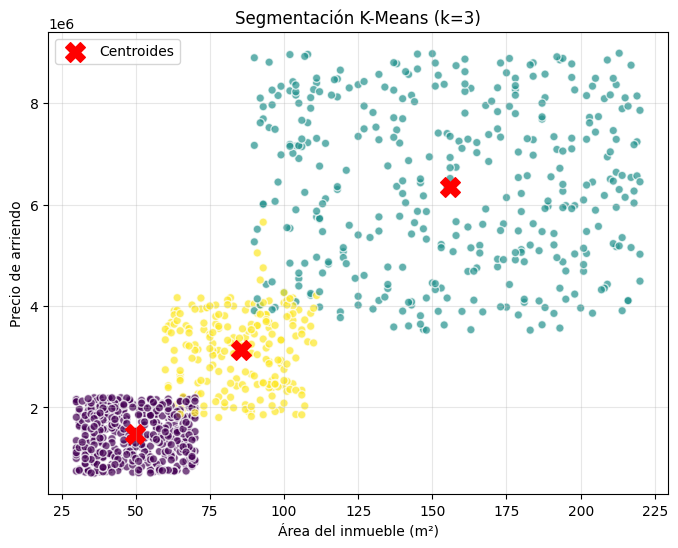


📊 RESULTADOS PARA n_clusters = 2

📏 Promedio por cluster (escala original):
            Área m²  Habitaciones   Estrato  Precio arriendo
cluster                                                     
0         60.980583      1.831715  2.983819     1.984490e+06
1        154.557592      4.010471  5.526178     6.300712e+06

🎯 Centroides en escala original:
      Área m²  Habitaciones   Estrato  Precio arriendo
0   60.980583      1.831715  2.983819     1.984490e+06
1  154.557592      4.010471  5.526178     6.300712e+06


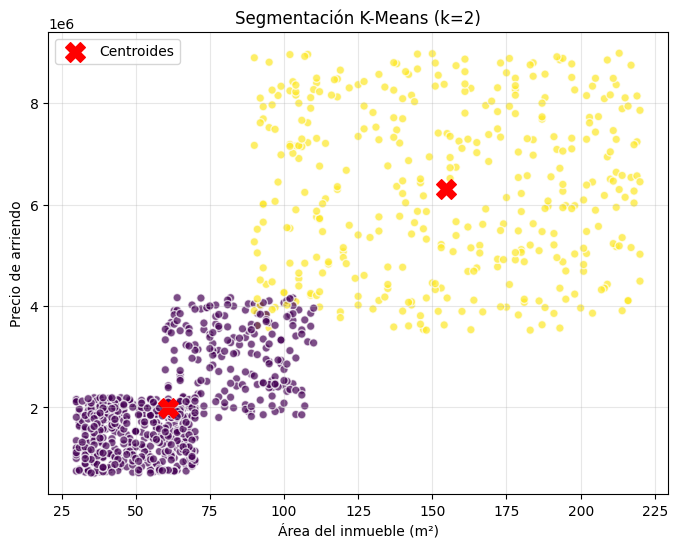


📊 RESULTADOS PARA n_clusters = 4

📏 Promedio por cluster (escala original):
            Área m²  Habitaciones   Estrato  Precio arriendo
cluster                                                     
0         49.658711      1.525060  2.501193     1.469202e+06
1        188.921053      3.952632  5.510526     6.392509e+06
2        121.058511      4.090426  5.553191     6.243451e+06
3         85.054187      2.487685  4.019704     3.100224e+06

🎯 Centroides en escala original:
      Área m²  Habitaciones   Estrato  Precio arriendo
0   49.658711      1.525060  2.501193     1.469202e+06
1  188.921053      3.952632  5.510526     6.392509e+06
2  121.058511      4.090426  5.553191     6.243451e+06
3   85.054187      2.487685  4.019704     3.100224e+06


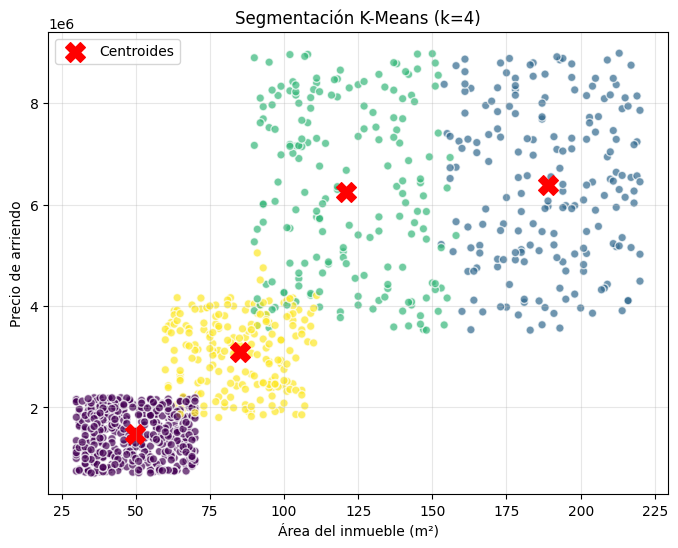

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ============================================================
# 1. Cargar dataset
# ============================================================
df = pd.read_excel('DATASET_INmuebles.xlsx')
# Limpiar espacios accidentales en nombres de columnas
df.columns = df.columns.str.strip()

# Verificar columnas cargadas
print("Columnas detectadas:", df.columns.tolist())

# ============================================================
# 2. Seleccionar variables para clustering
# ============================================================
features = ['Área m²', 'Habitaciones', 'Estrato', 'Precio arriendo']
X = df[features].copy()

# ============================================================
# 3. Escalamiento de datos
# ============================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# 4. Función para evaluar K-Means con diferentes k
# ============================================================
def evaluar_kmeans(k):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    df_res = df.copy()
    df_res['cluster'] = modelo.fit_predict(X_scaled)

    print(f"\n{'='*50}")
    print(f"📊 RESULTADOS PARA n_clusters = {k}")
    print(f"{'='*50}")

    # Resumen promedio por cluster
    resumen = df_res.groupby('cluster')[features].mean()
    print("\n📏 Promedio por cluster (escala original):")
    print(resumen)

    # Centroides en escala original
    centroides_orig = scaler.inverse_transform(modelo.cluster_centers_)
    df_centroides = pd.DataFrame(centroides_orig, columns=features)
    print("\n🎯 Centroides en escala original:")
    print(df_centroides)

    # Visualización Área vs Precio
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(df_res['Área m²'], df_res['Precio arriendo'],
                          c=df_res['cluster'], cmap='viridis', alpha=0.7, edgecolors='w')
    plt.scatter(centroides_orig[:, 0], centroides_orig[:, 3],
                c='red', marker='X', s=200, label='Centroides')
    plt.xlabel('Área del inmueble (m²)')
    plt.ylabel('Precio de arriendo')
    plt.title(f'Segmentación K-Means (k={k})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return df_res

# ============================================================
# 5. Ejecución para k=3 (caso base), k=2 y k=4
# ============================================================
df_k3 = evaluar_kmeans(3)
# Descomenta las siguientes líneas para ver k=2 y k=4
df_k2 = evaluar_kmeans(2)
df_k4 = evaluar_kmeans(4)